In [ ]:
#Cargamos el Dataset
import pandas as pd
df = pd.read_csv('DataSet_Limpio.csv')
df.head()

,ID_Cliente,Nombre_Cliente,Segmento,Pais,Region,Estado,Ciudad,ID_Pedido,Fecha_Pedido,ID_Producto,Nombre_Producto,Categoria,Subcategoria,Cantidad,Descuento,Ventas,Ganancia,Margen_Ganancia
0,C0174,Nicolás Martínez,Corporativo,Chile,Sur,Los Lagos,Puerto Montt,ORD-2023-00001,2025-03-31,P0082,Papelería Eco 2,Oficina,Papelería,1,0.00,590.86,322.42,54.567918
1,C0174,Nicolás Martínez,Corporativo,Chile,Sur,Los Lagos,Puerto Montt,ORD-2023-00001,2025-03-31,P0119,Sobres Plus 9,Oficina,Sobres,7,0.00,4341.68,1907.85,43.942667
2,C0174,Nicolás Martínez,Corporativo,Chile,Sur,Los Lagos,Puerto Montt,ORD-2023-00001,2025-03-31,P0048,Sillas Plus 8,Muebles,Sillas,2,0.00,1250.86,281.32,22.490127
3,C0174,Nicolás Martínez,Corporativo,Chile,Sur,Los Lagos,Puerto Montt,ORD-2023-00001,2025-03-31,P0079,Almacenamiento Nova 9,Muebles,Almacenamiento,5,0.00,244.35,64.85,26.539799
4,C0254,Isidora Rojas,Consumidor,Chile,Sur,Biobío,Concepción,ORD-2023-00002,2024-03-25,P0087,Papelería Flex 7,Oficina,Papelería,1,0.15,629.31,115.33,18.326421


In [ ]:
#Verificamos cantidad de columnas, nombre de las mismas, tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3026 entries, 0 to 3025
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Cliente       3026 non-null   object 
 1   Nombre_Cliente   3026 non-null   object 
 2   Segmento         3026 non-null   object 
 3   Pais             3026 non-null   object 
 4   Region           3026 non-null   object 
 5   Estado           3026 non-null   object 
 6   Ciudad           3026 non-null   object 
 7   ID_Pedido        3026 non-null   object 
 8   Fecha_Pedido     3026 non-null   object 
 9   ID_Producto      3026 non-null   object 
 10  Nombre_Producto  3026 non-null   object 
 11  Categoria        3026 non-null   object 
 12  Subcategoria     3026 non-null   object 
 13  Cantidad         3026 non-null   int64  
 14  Descuento        3026 non-null   float64
 15  Ventas           3026 non-null   float64
 16  Ganancia         3026 non-null   float64
 17  Margen_Gananci

In [ ]:
#Comportamiento general: Sacamos promedios, minimo, máximo
df.describe()

,Cantidad,Descuento,Ventas,Ganancia,Margen_Ganancia
count,3026.000000,3026.000000,3026.000000,3026.000000,3026.000000
mean,4.477198,0.099917,1898.627469,595.732905,30.008190
std,2.278097,0.102992,1556.813776,631.106966,14.766790
min,1.000000,0.000000,8.550000,-617.810000,-22.005279
25%,3.000000,0.000000,595.525000,125.045000,20.920253
50%,4.000000,0.100000,1479.955000,381.655000,31.311513
75%,6.000000,0.200000,2883.220000,884.485000,40.893297
max,8.000000,0.300000,7133.360000,3651.120000,54.903071


In [ ]:
#Comprobamos los valores nulos
df.isnull().sum()

,0
ID_Cliente,0
Nombre_Cliente,0
Segmento,0
Pais,0
Region,0
Estado,0
Ciudad,0
ID_Pedido,0
Fecha_Pedido,0
ID_Producto,0


In [ ]:
#Eliminamos datos duplicados
df = df.drop_duplicates()

Para el Clustering elegimos las columnas: Ventas, Ganancias y Margen Ganancia.

Comprobamos que son datos numericos, dado que Kmeans trabaja con solo datos numéricos, y que no queden valores nulos ni duplicados.

In [ ]:
#Importamos las herramientas Scikit-learn (StandarSkaler, Kmeans)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
#Variables elegidas
X = df[['Ventas', 'Ganancia', 'Margen_Ganancia']]
#Verificación
X.head()

,Ventas,Ganancia,Margen_Ganancia
0,590.86,322.42,54.567918
1,4341.68,1907.85,43.942667
2,1250.86,281.32,22.490127
3,244.35,64.85,26.539799
4,629.31,115.33,18.326421


In [ ]:
#Transformamos a las variables para que sean comparables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

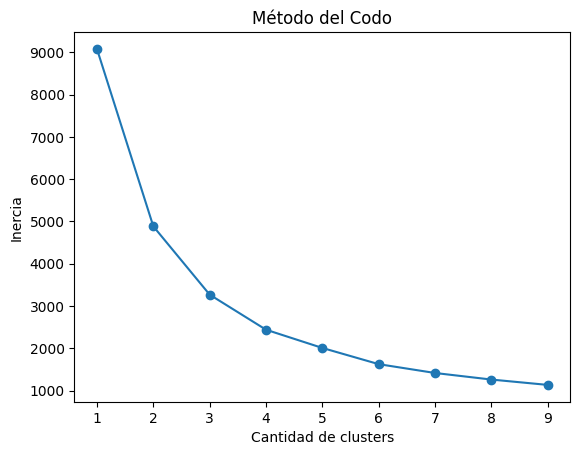

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)
#Gráfico
plt.plot(range(1, 10), inercia, marker='o')
plt.xlabel('Cantidad de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
#Resumen de clausters
resumen = df.groupby('Cluster')[['Ventas', 'Ganancia', 'Margen_Ganancia']].mean().round(2)
resumen

,Ventas,Ganancia,Margen_Ganancia
Cluster,,,
0,1465.01,185.10,12.65
1,4002.75,1493.51,37.75
2,1021.04,377.69,37.70


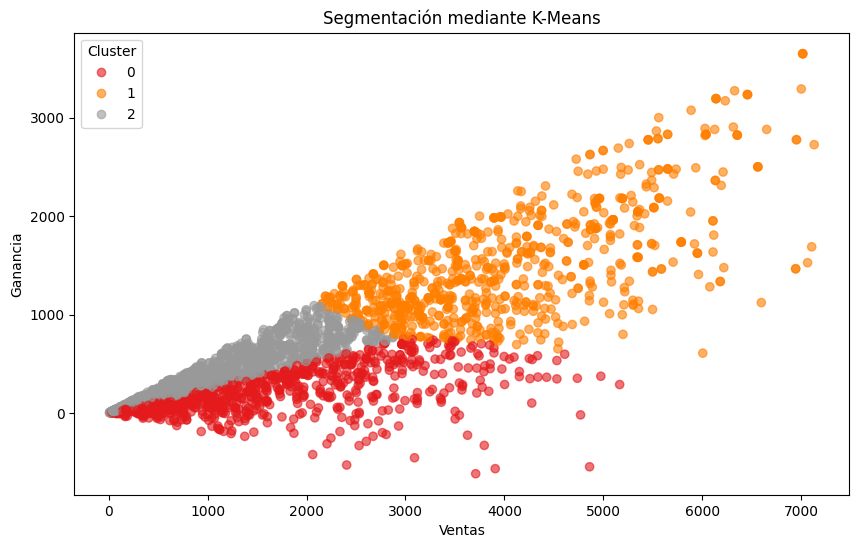

In [ ]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['Ventas'],
    df['Ganancia'],
    c=df['Cluster'],
    cmap='Set1',
    alpha=0.6
)

plt.xlabel('Ventas')
plt.ylabel('Ganancia')
plt.title('Segmentación mediante K-Means')

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.show()

**Fase 2: Interpretación de los clusters**

Cluster 0: Este segmento presenta una rentabilidad baja en comparación al resto

Cluster 1: Alto nivel de rentabilidad, el segmento de mayor peso económico para SuperTienda

Cluster 2: Este segmento tiene menores ventas que los anteriores pero no presenta un problema de rentabilidad que se podria esperar, tiene casi el mismo porcetanje de marge ganancia que el cluster 1. Esto representaría una oportunidad para analizar estrategias de ventas y aumentar ganancias

**Fase 3: C.H.I**

*Cluster 0*

Contexto: Ventas promedio de 1.465,01, una ganancia promedio de 185,10 y un margen de 12,65%.

Hallazgo: A pesar de tener un nivel de ventas superior al Cluster 2, genera una ganancia considerablemente menor y posee un margen de ganancia mucho más bajo.

Impacto: Esto puede afectar a la rentabilidad de SuperTienda, ya que un mayor volumen de ventas no se transforma en un mayor beneficio. Un segmento que necesita una revisión para obtener oportunidades de mejora

*Cluster 1: *

Contexto: El Cluster 1 presenta las mayores ventas promedio, con 4.002,75, y una ganancia promedio de 1.493,51, junto con un margen de 37,75%

Hallazgo: Alto volumen de ventas con una elevada rentabilidad, diferenciándose claramente de los demás segmentos

Impacto: Representa un pilar importante en la salud financiera de SuperTienda. Se debe mantener las condiciones para que siga de este modo, y reveer futuras estragias comerciales

*Cluster 2:*

Contexto: Este Cluster presenta las ventas promedio más bajas, con 1.021,04, pero alcanza una ganancia promedio de 377,69 y un margen de 37,70%.

Hallazgo: A pesar de tener el menor volumen de ventas, este segmento mantiene un margen de rentabilidad prácticamente igual al del Cluster 1

Impacto: Representa una oportunidad para la empresa, porque podria analizarse las operaciones llevadas a cabo para la rentabilidad y aumentar las ventas con el mismo nivel de margen de ganancia


Fase 4

*Recomendaciones*

Para Cluster 0: Revisar estrategias comerciales para ese sector, como los descuentos. Se debe mejorar el margen de ganancias.

Para cluster 2: Incrementar las ventas sosteniendo las condiciones que permiten ese margen de ganancia para no perder rentabilidad

Fase 5

Limitaciones en los datos: Para el análisis se tomaron las variables Ventas, Ganancia y Margen Ganancia y no se tuvieron en cuenta otras variables que podrian dar más detalles como los segmentos de clientes

Supuestos realizados: Se creyó suficiente en este análisis las tres variables para analizar diferencias entre clusters. Además se aplicó una estandarización a las tres variables elegidas para usar Kmeans y no se viera perjudicada la escala entre una y otra

Factores externos: Los resultados pueden variar por agentes externos como la inflación, comportamiento de los clientes, competencias etc. Debe tomarse este análisis como una interpretacion de los segmentos basados en datos y no un resultado definitivo y estable de la rentabilidad.